In [1]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

import cv2
import tensorflow as tf
from tqdm import tqdm
class_names = ['spiral_healthy','spiral_parkinson','wave_healthy','wave_parkinson']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (100, 100)

In [2]:
def load_data():

    datasets = ['test', 'train']

    output = []

    # Iterate through training and test sets
    for dataset in datasets:

        images = []
        labels = []

        print("Loading {}".format(dataset))

        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            label = class_names_label[folder]

            # Iterate through each image in our folder
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):

                # Get the path name of the image
                img_path = os.path.join(os.path.join(dataset, folder), file)

                # Open and resize the img
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)

        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')

        output.append((images, labels))

    return output

In [3]:
(train_images, train_labels), (test_images, test_labels) = load_data()

Loading test


100%|██████████████████████████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 34.07it/s]


Loading train


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 49.34it/s]


In [4]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])
cnn_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
history = cnn_model.fit(train_images, train_labels, batch_size=128, epochs=50, validation_split = 0.2)
cnn_model.save("final_model.h5")

C:\Users\deeks\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.2418 - loss: 306.6519 - val_accuracy: 0.0000e+00 - val_loss: 2746.4463
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.4426 - loss: 546.1823 - val_accuracy: 0.0000e+00 - val_loss: 2145.2090
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4877 - loss: 235.5403 - val_accuracy: 0.0000e+00 - val_loss: 2022.8802
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4426 - loss: 331.1175 - val_accuracy: 0.0000e+00 - val_loss: 1194.6824
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.4467 - loss: 80.9293 - val_accuracy: 0.0000e+00 - val_loss: 657.4949
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.2828 - loss: 50.8733 - val_accuracy: 0.2742 - val_loss: 474.9852
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.2582 - loss: 24.1762 - val_accuracy: 0.0000e+00 - val_loss: 315.8478
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.5

In [5]:
cnn_model.save("final_model.h5")

# XGBoost classifier

In [6]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def load_images_from_folder(folder):
    images = []
    labels = []
    for label in os.listdir(folder):
        label_folder = os.path.join(folder, label)
        if os.path.isdir(label_folder):
            for filename in os.listdir(label_folder):
                img_path = os.path.join(label_folder, filename)
                if img_path.endswith(".jpg") or img_path.endswith(".png"):
                    image = cv2.imread(img_path)
                    if image is not None:
                        images.append(image)
                        labels.append(label)
    return images, labels

def preprocess_images(images, size=(100, 100)):
    processed_images = []
    for image in images:
        resized_image = cv2.resize(image, size)
        normalized_image = resized_image / 255.0  # Normalize
        processed_images.append(normalized_image)
    return np.array(processed_images)


dataset_folder = "train"
images, labels = load_images_from_folder(dataset_folder)


preprocessed_images = preprocess_images(images)


n_samples = preprocessed_images.shape[0]
X = preprocessed_images.reshape(n_samples, -1)  # (n, 100*100*3)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)


sample = X_test[0].reshape(1, -1)
pred_label = label_encoder.inverse_transform(model.predict(sample))
print("Sample Prediction:", pred_label[0])


Train shape: (81, 30000)
Test shape: (21, 30000)


C:\Users\deeks\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:42:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.5714285714285714
Sample Prediction: spiral_parkinson


# using xboost

In [7]:
import pickle
with open("xgb_model.pkl", "wb") as f:
    pickle.dump((model, label_encoder), f)

print("✅ Model saved as xgb_model.pkl")

def predict_image(image_path, model_file="xgb_model.pkl", size=(100,100)):
    with open(model_file, "rb") as f:
        model, label_encoder = pickle.load(f)
    
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found at path: " + image_path)
    
    resized = cv2.resize(image, size)
    normalized = resized / 255.0
    flattened = normalized.reshape(1, -1)
    
    pred = model.predict(flattened)
    label = label_encoder.inverse_transform(pred)
    return label[0]

# Example usage
test_img = r"C:\Users\deeks\Downloads\DETECTING PARKINSON'S DISEASE USING XGBOOST CLASSIFIER MACHINE LEARNING\DETECTING PARKINSON'S DISEASE USING XGBOOST CLASSIFIER MACHINE LEARNING\test\wave_healthy\V01HO01 - Copy.png"
print("Prediction for test image:", predict_image(test_img))


✅ Model saved as xgb_model.pkl
Prediction for test image: wave_healthy


# using cnn 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[2]


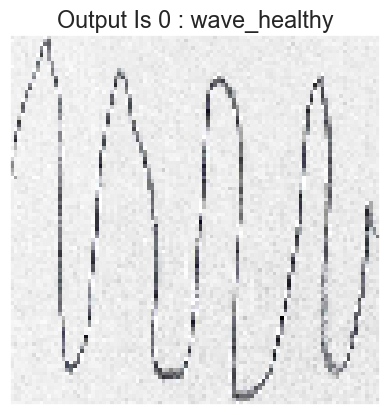

In [8]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
test_image = image.load_img(r"C:\Users\deeks\Downloads\DETECTING PARKINSON'S DISEASE USING XGBOOST CLASSIFIER MACHINE LEARNING\DETECTING PARKINSON'S DISEASE USING XGBOOST CLASSIFIER MACHINE LEARNING\test\wave_healthy\V01HO01 - Copy.png", target_size = (100, 100))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
predictions = cnn_model.predict(test_image)   
pred_labels = np.argmax(predictions, axis = 1) 
print(pred_labels )
index = np.random.randint(test_image.shape[0])
plt.figure()
plt.imshow(test_image[index].astype('uint8'))
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title('Output Is {} : '.format(index) + class_names[pred_labels[index]])
plt.show()

In [ ]:
import tkinter as tk
from tkinter import filedialog
from tkinter import Label, Button
from PIL import Image, ImageTk
import cv2
import pickle


with open("xgb_model.pkl", "wb") as f:
    pickle.dump((model, label_encoder), f)

print("✅ Model saved as xgb_model.pkl")


def predict_image(image_path, model_file="xgb_model.pkl", size=(100,100)):
    with open(model_file, "rb") as f:
        model, label_encoder = pickle.load(f)
    
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found at path: " + image_path)
    
    resized = cv2.resize(image, size)
    normalized = resized / 255.0
    flattened = normalized.reshape(1, -1)
    
    pred = model.predict(flattened)
    label = label_encoder.inverse_transform(pred)
    return label[0]


root = tk.Tk()
root.title("🧠 DETECTING PARKINSON'S DISEASE USING XGBOOST CLASSIFIER MACHINE LEARNING")
root.geometry("950x700")
root.config(bg="#3c1361") 

selected_image_path = None


title_label = Label(root, text="🧠 Detecting Parkinson's Disease 🧠\nUsing XGBoost Classifier",
                    font=("Helvetica", 20, "bold"), fg="white", bg="#3c1361")
title_label.pack(pady=20)

img_label = Label(root, bg="#3c1361")
img_label.pack(pady=10)


result_label = Label(root, text="", font=("Helvetica", 18, "bold"),
                     fg="white", bg="#3c1361")
result_label.pack(pady=10)


info_text = """📖 Parkinson's disease affects motor control. 
This project uses XGBoost ML to analyze hand wave images
and predict if a person is Healthy ✅ or Parkinson’s Positive ⚠️."""
info_label = Label(root, text=info_text, font=("Arial", 12),
                   fg="#d8b4fe", bg="#3c1361", justify="center")  # light purple text
info_label.pack(pady=10)


def browse_file():
    global selected_image_path
    file_path = filedialog.askopenfilename(
        filetypes=[("Image files", "*.png;*.jpg;*.jpeg")]
    )
    if file_path:
        selected_image_path = file_path
        img = Image.open(file_path)
        img = img.resize((280, 280))
        img_tk = ImageTk.PhotoImage(img)
        img_label.config(image=img_tk)
        img_label.image = img_tk
        result_label.config(text="")  # Clear old result


def predict_action():
    if selected_image_path:
        try:
            prediction = predict_image(selected_image_path)
            emoji = "✅" if prediction.lower() == "healthy" else "⚠️"
            result_label.config(
                text=f"Prediction: {emoji} {prediction}",
                fg="#a3f7bf" if prediction.lower() == "healthy" else "#ff6b81"  
            )
        except Exception as e:
            result_label.config(text="Error: " + str(e), fg="red")
    else:
        result_label.config(text="⚠️ Please select an image first!", fg="yellow")


browse_btn = Button(root, text="📂 Browse Image", command=browse_file,
                    font=("Arial", 14, "bold"), bg="#5e60ce", fg="white",
                    relief="flat", padx=15, pady=5)  # soft purple button
browse_btn.pack(pady=10)

predict_btn = Button(root, text="🤖 Predict", command=predict_action,
                     font=("Arial", 14, "bold"), bg="#7400b8", fg="white",
                     relief="flat", padx=15, pady=5)  # deep purple button
predict_btn.pack(pady=10)

root.mainloop()


✅ Model saved as xgb_model.pkl
